# ========= Word Embeddings and Representation Learning =========

# Labraries

In [25]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Load Dataset

In [26]:
cols = ['target', 'id', 'date', 'flag', 'user', 'text']

df = pd.read_csv(
    "/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv",
    encoding='latin-1',
    names=cols,
    usecols=['target', 'text']
)

df.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


Label fix

In [28]:
df['target'] = df['target'].replace(4, 1)
df['target'].value_counts()

target
0    800000
1    800000
Name: count, dtype: int64

sample data

In [29]:
df = df.sample(100000, random_state=42) 
df = df.reset_index(drop=True)

print(df.shape)

(100000, 2)


# Preprocessing

In [30]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

In [32]:
df['clean_text'] = df['text'].apply(preprocess)

df[['text', 'clean_text']].head()

,text,clean_text
0,@chrishasboobs AHHH I HOPE YOUR OK!!!,chrishasboobs ahhh hope ok
1,"@misstoriblack cool , i have no tweet apps fo...",misstoriblack cool tweet apps razr
2,@TiannaChaos i know just family drama. its la...,tiannachaos know family drama lamehey next tim...
3,School email won't open and I have geography ...,school email wont open geography stuff revise ...
4,upper airways problem,upper airways problem


# Train Test Split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['target'],
    test_size=0.2,
    random_state=42
)

====================================================================

   #  MODULE 1: FREQUENCY-BASED EMBEDDINGS
     
====================================================================

# Bag of Words

In [34]:
bow = CountVectorizer(max_features=10000) 

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# Train Model (BoW)

In [35]:
model_bow = LogisticRegression(max_iter=200)
model_bow.fit(X_train_bow, y_train)

LogisticRegression(max_iter=200)

# Evaluate (BoW)

In [36]:
y_pred_bow = model_bow.predict(X_test_bow)

print("BoW Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_bow))
print("Precision:", precision_score(y_test, y_pred_bow))
print("Recall:", recall_score(y_test, y_pred_bow))
print("F1:", f1_score(y_test, y_pred_bow))

BoW Results:
Accuracy: 0.7573
Precision: 0.745777268823361
Recall: 0.7811094452773614
F1: 0.7630345635618043


# TF-IDF

In [37]:
tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Model (TF-IDF)

In [38]:
model_tfidf = LogisticRegression(max_iter=200)
model_tfidf.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=200)

# Evaluate (TF-IDF)

In [39]:
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)

print("TF-IDF Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_tfidf))
print("Precision:", precision_score(y_test, y_pred_tfidf))
print("Recall:", recall_score(y_test, y_pred_tfidf))
print("F1:", f1_score(y_test, y_pred_tfidf))

TF-IDF Results:
Accuracy: 0.7614
Precision: 0.7524848016983499
Recall: 0.7794102948525737
F1: 0.7657109190887667


# Confusion Matrix

In [42]:
from sklearn.metrics import confusion_matrix

print("BoW Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bow))
print("TF-IDF Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tfidf))

BoW Confusion Matrix:
 [[7331 2664]
 [2190 7815]]
TF-IDF Confusion Matrix:
 [[7430 2565]
 [2207 7798]]


# Co-occurrence Matrix

In [43]:
# Take smaller sample 
small_df = df.sample(5000, random_state=42).reset_index(drop=True)

# Build vocabulary (limit size)
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(max_features=2000)
X = vectorizer.fit_transform(small_df['clean_text'])

vocab = vectorizer.get_feature_names_out()
word_to_idx = {word: i for i, word in enumerate(vocab)}

import numpy as np

co_matrix = np.zeros((len(vocab), len(vocab)), dtype=np.int32)

window_size = 2

# Build Co-occurrence Matrix
for text in small_df['clean_text']:
    tokens = text.split()
    for i, word in enumerate(tokens):
        if word not in word_to_idx:
            continue
        for j in range(max(0, i - window_size), min(len(tokens), i + window_size + 1)):
            if i != j:
                neighbor = tokens[j]
                if neighbor in word_to_idx:
                    co_matrix[word_to_idx[word], word_to_idx[neighbor]] += 1

print("Co-occurrence matrix shape:", co_matrix.shape)

Co-occurrence matrix shape: (2000, 2000)


In [44]:
word = "good"

if word in word_to_idx:
    idx = word_to_idx[word]
    top_indices = co_matrix[idx].argsort()[-10:]

    print("Words co-occurring with 'good':")
    for i in top_indices:
        print(vocab[i])

Words co-occurring with 'good':
today
hope
work
like
really
im
night
day
luck
morning


====================================================================

   #  Module 2: Prediction-Based Embeddings
     
====================================================================

# Labraries

In [45]:
!pip install gensim

import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

2026-04-05 13:48:15.426515: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775396895.616315      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775396895.670384      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775396896.089026      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775396896.089058      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775396896.089061      56 computation_placer.cc:177] computation placer alr

# Prepare Tokenized Data

In [46]:
# Use already cleaned data from Module 1

sentences = [text.split() for text in df['clean_text']]

print(sentences[0])

['chrishasboobs', 'ahhh', 'hope', 'ok']


# Train Word2Vec Model

In [47]:
w2v_model = Word2Vec(
    sentences,
    vector_size=100,   # embedding size
    window=5,
    min_count=2,
    workers=4
)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 27323


 Word Embedding Example

In [48]:
print(w2v_model.wv['good']) 

[-0.9404457   0.823211   -0.08918847 -0.44868731  0.5992608  -1.0594689
  0.10302825  1.8604156  -0.04790697 -0.8319844  -0.3464969  -1.0256515
 -0.19337921  1.182317    0.28538373  0.35169294  0.47797933 -0.2263336
  0.39544967 -1.3525906   1.5534263  -0.3881662   0.94438803 -0.7296565
 -0.55023015  0.27231383 -1.1758901  -0.4583817  -0.88245916  0.4605942
  0.943001   -0.35915372  1.1214551  -1.8785298  -0.15139642  0.8531287
 -0.2933542   0.58639914  0.59638345 -0.1741849   1.5639821  -0.6011216
 -1.8000377  -0.28599268  0.69851756  0.5464264   0.56412894 -0.74263066
  0.9771292   0.5299002   0.9843891  -1.2524704  -0.07736567 -0.18972534
  0.96798617  0.4153306   1.1132427   0.5944649  -0.793188   -0.13275138
 -0.58204347 -0.03826668 -0.26495633 -0.03783225 -1.6097828   0.27175853
  1.2089446  -0.17914782  0.02231476  2.464308   -0.44859913 -1.2068087
  1.0528939   0.5264289   0.9780146   0.23038375 -0.40321198 -0.08368134
 -0.27474773  0.3699987  -0.59911627 -0.08716499 -0.3783363

# Convert Sentence → Vector

In [49]:
def sentence_vector(sentence, model):
    words = sentence.split()
    vectors = []

    for word in words:
        if word in model.wv:
            vectors.append(model.wv[word])

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

# Feature Matrix

In [52]:
X_w2v = np.array([sentence_vector(text, w2v_model) for text in df['clean_text']])
y = df['target']

print(X_w2v.shape)

(100000, 100)


# Train/Test Split

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42
)

# Neural Network Model (FNN)

In [54]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775397084.358009      56 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/5


I0000 00:00:1775397086.482122     368 service.cc:152] XLA service 0x7c25b000a0e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775397086.482150     368 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775397086.745253     368 cuda_dnn.cc:529] Loaded cuDNN version 91002


  80/2250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5906 - loss: 0.6663

I0000 00:00:1775397087.285868     368 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2250/2250 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.6850 - loss: 0.5855 - val_accuracy: 0.6950 - val_loss: 0.5667
Epoch 2/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7159 - loss: 0.5507 - val_accuracy: 0.6935 - val_loss: 0.5753
Epoch 3/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7198 - loss: 0.5469 - val_accuracy: 0.7119 - val_loss: 0.5541
Epoch 4/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7210 - loss: 0.5436 - val_accuracy: 0.7143 - val_loss: 0.5461
Epoch 5/5
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7211 - loss: 0.5428 - val_accuracy: 0.7104 - val_loss: 0.5535


# Evaluation

In [55]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print("Word2Vec Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Word2Vec Results:
Accuracy: 0.71495
Precision: 0.6858697529797892
Recall: 0.7937031484257872
F1: 0.7358569244312654


# Visualization (PCA)

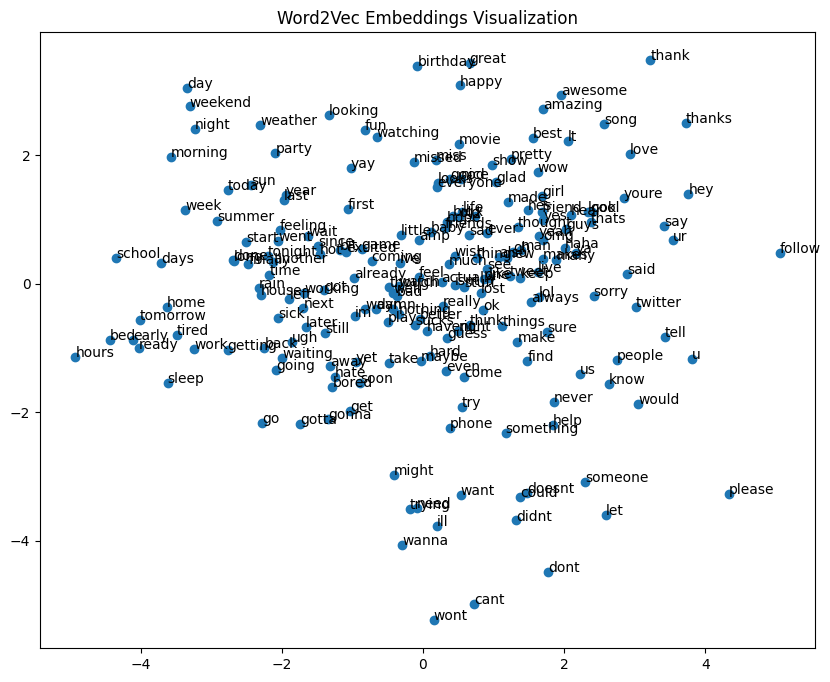

In [56]:
words = list(w2v_model.wv.index_to_key)[:200]  # take 200 words
vectors = w2v_model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(vectors)

plt.figure(figsize=(10,8))
plt.scatter(result[:, 0], result[:, 1])

for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

plt.title("Word2Vec Embeddings Visualization")
plt.show()

# GloVe (Pretrained)

In [59]:
embedding_index = {}

with open('/kaggle/input/datasets/rtatman/glove-global-vectors-for-word-representation/glove.6B.100d.txt', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

print("Loaded GloVe words:", len(embedding_index))

Loaded GloVe words: 400000


# Sentence Vector (GloVe)

In [60]:
def glove_sentence_vector(sentence):
    words = sentence.split()
    vectors = []

    for word in words:
        if word in embedding_index:
            vectors.append(embedding_index[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

# Features + Train Model (GloVe)

In [61]:
X_glove = np.array([glove_sentence_vector(text) for text in df['clean_text']])

X_train, X_test, y_train, y_test = train_test_split(
    X_glove, y, test_size=0.2, random_state=42
)

model_glove = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dense(1, activation='sigmoid')
])

model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_glove.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.6638 - loss: 0.6045
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7028 - loss: 0.5690
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7146 - loss: 0.5554
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7175 - loss: 0.5479
Epoch 5/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7235 - loss: 0.5418


# Evaluate (GloVe)

In [62]:
y_pred = (model_glove.predict(X_test) > 0.5).astype(int)

print("GloVe Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
GloVe Results:
Accuracy: 0.70795
Precision: 0.7580565195835399
Recall: 0.6112943528235882
F1: 0.6768107121119903


====================================================================

   #  MODULE 3 — Contextual Embeddings (BERT)
     
====================================================================

# Labraries

In [73]:
!pip install transformers --quiet

import torch
import numpy as np
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load BERT

In [78]:
# Load tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

model.eval()

# FORCE CPU to avoid CUDA errors
device = torch.device("cpu")
model.to(device)
print("Using device:", device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


# Batch Embedding Function

In [79]:
def get_bert_embeddings_batch(texts, batch_size=64, max_length=50):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        inputs = tokenizer(batch_texts, return_tensors='pt',
                           truncation=True, padding=True, max_length=max_length)
        # Move inputs to CPU
        inputs = {key: val.to(device) for key, val in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # CLS token
        all_embeddings.append(cls_embeddings.cpu().numpy())
    
    return np.vstack(all_embeddings)

# Prepare Dataset

In [80]:
# 10k samples for speed
small_df = df.sample(10000, random_state=42).reset_index(drop=True)
small_df['clean_text'] = small_df['text'].str.lower()

# Extract BERT Embeddings

In [81]:
X_bert = get_bert_embeddings_batch(
    small_df['clean_text'].tolist(), batch_size=64, max_length=50
)
y = small_df['target'].values

print("Shape of BERT features:", X_bert.shape) 

Shape of BERT features: (10000, 768)


# Train/Test Split

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bert, y, test_size=0.2, random_state=42
)

# Classifier (Logistic Regression)

In [83]:
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

# Evaluation

In [84]:
y_pred = clf.predict(X_test)

print("BERT Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

BERT Results:
Accuracy: 0.781
Precision: 0.7572815533980582
Recall: 0.8057851239669421
F1: 0.7807807807807807


# Polysemy Check

In [85]:
sentence1 = "He went to the bank to deposit money"
sentence2 = "He sat by the river bank"

emb1 = get_bert_embedding(sentence1)
emb2 = get_bert_embedding(sentence2)

from numpy.linalg import norm

similarity = np.dot(emb1, emb2) / (norm(emb1) * norm(emb2))

print("Cosine Similarity:", similarity)

Cosine Similarity: 0.9588806


In [86]:
np.save("X_distilbert.npy", X_bert)
np.save("y_distilbert.npy", y)
print("Embeddings saved for reuse.")

Embeddings saved for reuse.
